# **Data Preparation**

In [ ]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

### 1. Define Directory Paths

In [ ]:
!unzip -q banana_dataset.zip -d dataset/

In [ ]:
base_dir = '/content/dataset'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'valid')

### 2. Setting-up Image Parameters (416x416 px)

In [ ]:
IMG_HEIGHT = 416
IMG_WIDTH = 416
BATCH_SIZE = 32

### 3. Configure Data Generators

In [ ]:
# augmenting the training data to avoid overfitting
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation data is ONLY rescaled. No augmentation
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

### 4. Load the Data

In [ ]:
print("Loading Training Data for CNN...")
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print("\nLoading Validation Data for CNN...")
val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\nLoading Validation Data for CNN...")
test_data = test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Extracting the number of classes dynamically (it will be 4: overripe, ripe, rotten, unripe)
NUM_CLASSES = train_data.num_classes

Loading Training Data for CNN...
Found 11793 images belonging to 4 classes.

Loading Validation Data for CNN...
Found 1123 images belonging to 4 classes.

Loading Validation Data for CNN...
Found 1123 images belonging to 4 classes.


# **CUSTOM CNN ARCHITECTURE & TRAINING**

### 01 Build the Custom CNN Architecture

In [ ]:
print("\nBuilding Custom CNN Architecture...")
model_cnn = Sequential([
    # First Convolutional Layer
    # to extract basic features [edges and colors]
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    BatchNormalization(), # Stabilizes learning by normalizing activations
    MaxPooling2D(pool_size=(2, 2)), # Reduces image dimensions to save computation

    # Second Convolutional Layer
    # to extract more complex features [shapes and textures] (e.g., banana spots)
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    # Third Convolutional Layer
    # to extract highly abstract features [fruit's ripeness]
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    # CLASSIFICATION HEAD
    Flatten(), # Converts the 2D feature maps into a 1D vector
    Dense(128, activation='relu'), # Fully connected layer to interpret features
    Dropout(0.5), # Randomly drops 50% of connections to prevent overfitting
    Dense(NUM_CLASSES, activation='softmax') # Final output layer (Softmax gives probabilities for the 4 classes)
])

# Display a summary of the model architecture
model_cnn.summary()


Building Custom CNN Architecture...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 414, 414, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 414, 414, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 207, 207, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 205, 205, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 205, 205, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 102, 102, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 100, 100, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 320000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    40,960,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,054,788 (156.61 MB)

 Trainable params: 41,054,340 (156.61 MB)

 Non-trainable params: 448 (1.75 KB)

### Compiling the Model

In [ ]:
# Adam is used, as it is a standard, highly efficient optimizer.
# Categorical crossentropy is used for multi-class classification.
model_cnn.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

### Setting up Callbacks

In [ ]:
callbacks = [
    # Stops training early if validation accuracy stops improving for 10 epochs, preventing overfitting.
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, mode='max'),

    # Saves the model automatically, but ONLY if it achieved a better validation accuracy than before.
    ModelCheckpoint('custom_cnn_model.keras', monitor='val_accuracy', save_best_only=True, mode='max')
]

### Training the Model

In [ ]:
print("\nStarting Model Training...")
# Increased for more extensive training
EPOCHS = 50

history_cnn = model_cnn.fit(
    train_data,
    epochs=EPOCHS,
    validation_data=val_data,
    callbacks=callbacks
)


Starting Model Training...
Epoch 1/50
369/369 ━━━━━━━━━━━━━━━━━━━━ 503s 1s/step - accuracy: 0.6410 - loss: 0.9919 - val_accuracy: 0.7792 - val_loss: 0.5837
Epoch 2/50
369/369 ━━━━━━━━━━━━━━━━━━━━ 487s 1s/step - accuracy: 0.6807 - loss: 0.8529 - val_accuracy: 0.7703 - val_loss: 0.7112
Epoch 3/50
369/369 ━━━━━━━━━━━━━━━━━━━━ 498s 1s/step - accuracy: 0.6621 - loss: 0.8744 - val_accuracy: 0.7943 - val_loss: 0.8885
Epoch 4/50
369/369 ━━━━━━━━━━━━━━━━━━━━ 482s 1s/step - accuracy: 0.6305 - loss: 0.9015 - val_accuracy: 0.6278 - val_loss: 2.2595
Epoch 5/50
369/369 ━━━━━━━━━━━━━━━━━━━━ 486s 1s/step - accuracy: 0.6851 - loss: 0.8086 - val_accuracy: 0.3695 - val_loss: 2.2315
Epoch 6/50
369/369 ━━━━━━━━━━━━━━━━━━━━ 487s 1s/step - accuracy: 0.6735 - loss: 0.8567 - val_accuracy: 0.7631 - val_loss: 1.0718
Epoch 7/50
369/369 ━━━━━━━━━━━━━━━━━━━━ 505s 1s/step - accuracy: 0.7038 - loss: 0.7707 - val_accuracy: 0.8388 - val_loss: 0.7494
Epoch 8/50
369/369 ━━━━━━━━━━━━━━━━━━━━ 489s 1s/step - accuracy: 0.73

# EVALUATION & VISUALIZATION

### Plotting the Learning Curves


Plotting Training History...


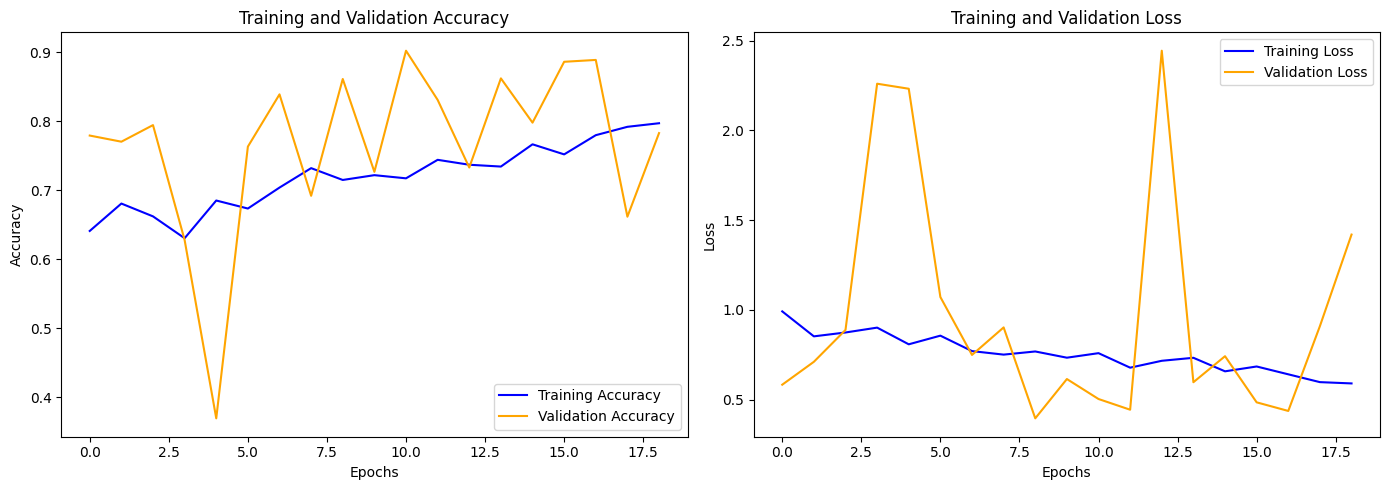


Training Complete! Best model saved as 'custom_cnn_model.keras'.


In [ ]:
print("\nPlotting Training History...")

# Extract metrics from the training history
acc = history_cnn.history['accuracy']
val_acc = history_cnn.history['val_accuracy']
loss = history_cnn.history['loss']
val_loss = history_cnn.history['val_loss']

epochs_range = range(len(acc))

# Create a figure with two subplots (Accuracy and Loss)
plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()

print("\nTraining Complete! Best model saved as 'custom_cnn_model.keras'.")